# Phase 5 — Experiment tracking, or: where did that number come from?

Phase 4 compared three loss functions. The comparison lived in a Python dict, was
printed as a table, and is now gone — the kernel that held it has been restarted.
What survives on disk is `models/history_mse.csv` and `models/molecular_net_mse.pt`.
Neither file records that it came from `learning_rate=1e-3`, `dropout=0.1`,
`split_seed=0`. That link only ever existed in the notebook cell above it.

Three runs, one sitting, one person: this is fine. The failure is not dramatic, it
is arithmetic. This notebook runs **nine** configurations. Nine `.pt` files whose
names I chose by hand, nine histories, and a comparison I would have to keep in my
head — with nothing on disk connecting any checkpoint back to the settings that
produced it.

**What MLflow is:** a database of training runs plus a UI over it. Not a training
framework. It does not touch the training loop — the loop below still knows
nothing about it. Each *run* records four things:

| kind | what it is | example |
|---|---|---|
| **params** | the inputs; written once, immutable | `learning_rate=0.001` |
| **metrics** | the outputs; each a time series indexed by step | `mae_ev` per epoch |
| **tags** | free-form labels, for grouping | `sweep=lr-width` |
| **artifacts** | files attached to the run | the `.pt` checkpoint |

The params/metrics split is the one that matters, and it is not bureaucratic: it
is exactly what lets the UI plot nine validation curves on one axis and colour
them by learning rate.

**Why not just a CSV?** You can get a long way with one, and for nine runs it
would honestly work. It stops working when two runs write concurrently, when you
want *"every run with dropout > 0.1, sorted by validation MAE"*, and when you need
to get from a row in that table back to the checkpoint it describes. Those three
are the whole job.

*Runtime: about 57 minutes for the nine-run sweep on a laptop CPU. Runs are read back from the MLflow store on re-execution rather than retrained.*


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from molecular_property_predictor.baseline import split_positions
from molecular_property_predictor.data import load_qm9
from molecular_property_predictor.features import load_features
from molecular_property_predictor.model import predict
from molecular_property_predictor.train import TrainingConfig
from molecular_property_predictor.tracking import (
    DEFAULT_TRACKING_DIR,
    best_run,
    configure,
    load_run_artifact,
    make_grid,
    search_runs,
    sweep,
    tracking_uri,
)

plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

df = load_qm9()
train_rows, validation_rows, _ = split_positions(df, seed=0)
features = load_features(df, "sorted_coulomb")
actual = df["lumo"].to_numpy()[validation_rows]

experiment_id = configure()
print(f"tracking store : {tracking_uri()}")
print(f"experiment id  : {experiment_id}")
print(f"train {len(train_rows):,}  validation {len(validation_rows):,}")

2026/08/10 20:12:12 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/08/10 20:12:12 INFO mlflow.store.db.utils: Updating database tables


tracking store : sqlite:///C:/Users/rahul/OneDrive/Desktop/Project/molecular-property-predictor/mlruns/mlflow.db
experiment id  : 1
train 104,664  validation 13,083


## Where the runs are stored

`mlruns/mlflow.db` holds the run *records*; `mlruns/artifacts/` holds the *files*
those records point at. No server process — `mlflow ui` reads the database
directly.

That split between a database and a directory is worth pausing on, because it is
not a local quirk. Run metadata wants transactions and queries; a 1.5 MB
checkpoint wants a filesystem. A production deployment makes exactly the same
split with Postgres and S3 standing in for the two halves. Same shape, different
scale.

The cheaper-looking option — MLflow's plain-directory "file store", one folder per
run — is what this project first reached for, and MLflow 3.x refuses it unless you
set an opt-out environment variable. The reason is the reason a CSV is a poor run
log: a directory tree has no transactions and no query engine, so concurrent
writes race and every filter means walking every run. SQLite is still a single
local file with nothing to administer, and it gives you both.

`mlruns/` is gitignored. It is a record of *local* runs and largely binary;
committing it would turn every experiment into a commit.

## The seam

The whole integration with the training loop is one argument:

```python
run = train_model(
    frame, config, ...,
    on_epoch=lambda epoch, metrics: mlflow.log_metrics(metrics, step=epoch),
)
```

`train_model` takes an `on_epoch` callback and calls it after each epoch. It does
not import MLflow and does not know what the callback does. Swapping MLflow for
Weights & Biases, or for nothing at all, would not change a line of `train.py`.

This is a deliberate choice and the alternative is genuinely tempting: inlining
`mlflow.log_metrics` into the loop is fewer moving parts today. The cost shows up
when the training code has to run somewhere the tracking server does not exist —
a unit test, a debug session, a batch job on a cluster node with no network.

## The grid

Three learning rates against three network widths. `loss_name` stays `mse`, which
Phase 4 measured as the best of the three losses — one axis at a time.

A full grid rather than a random search: with two axes and three values each,
exhaustive is both cheap and easier to reason about. Random search wins once the
space is large enough that most axes turn out not to matter, which is not yet.

Note that the default configuration — `1e-3`, `(512, 256, 128)` — is one of the
nine. It reproduces Phase 4's MSE run, so the sweep contains a point whose answer
is already known. That is a free check on the machinery.

In [2]:
base = TrainingConfig(
    representation="sorted_coulomb", loss_name="mse", max_epochs=100, patience=10
)

grid = make_grid(
    base,
    learning_rate=(1e-2, 1e-3, 3e-4),
    hidden_sizes=((256, 128), (512, 256, 128), (1024, 512, 256)),
)

display(
    pd.DataFrame(
        [
            {
                "learning_rate": c.learning_rate,
                "hidden_sizes": str(c.hidden_sizes),
                "dropout": c.dropout,
                "loss": c.loss_name,
            }
            for c in grid
        ]
    ).style.set_caption(f"{len(grid)} configurations to train")
)

,learning_rate,hidden_sizes,dropout,loss
0,0.010000,"(256, 128)",0.100000,mse
1,0.010000,"(512, 256, 128)",0.100000,mse
2,0.010000,"(1024, 512, 256)",0.100000,mse
3,0.001000,"(256, 128)",0.100000,mse
4,0.001000,"(512, 256, 128)",0.100000,mse
5,0.001000,"(1024, 512, 256)",0.100000,mse
6,0.000300,"(256, 128)",0.100000,mse
7,0.000300,"(512, 256, 128)",0.100000,mse
8,0.000300,"(1024, 512, 256)",0.100000,mse


Everything not in that table is held fixed and, crucially, still **recorded** on
every run: `dropout`, `batch_size`, `patience`, `split_seed`, `torch_seed`. Logging
the constants matters as much as logging the variables. A month from now, "did
these use the same split?" has to be answerable from the record, not from memory.

In [3]:
# 2-15 minutes per run on CPU; 56 minutes for the nine. Each config becomes
# its own MLflow run, tagged `sweep=lr-width` so the group can be pulled
# back out later.
results = sweep(
    df,
    grid,
    varied=["learning_rate", "hidden_sizes"],
    sweep_name="lr-width",
    report=print,
)

display(
    results.style
    .format({"val_mae_ev": "{:.4f}", "val_r2": "{:.4f}", "seconds": "{:.0f}"})
    .set_caption("Sweep results, sorted by validation MAE")
)

[1/9] lr-width-le0.01-hi256x128


    MAE 0.3759 eV  R2 0.8453  (121s)
[2/9] lr-width-le0.01-hi512x256x128


    MAE 0.3689 eV  R2 0.8488  (214s)
[3/9] lr-width-le0.01-hi1024x512x256


    MAE 0.4278 eV  R2 0.8121  (167s)
[4/9] lr-width-le0.001-hi256x128


    MAE 0.3003 eV  R2 0.8965  (227s)
[5/9] lr-width-le0.001-hi512x256x128


...

    MAE 0.2476 eV  R2 0.9182  (907s)
[7/9] lr-width-le0.0003-hi256x128


    MAE 0.3144 eV  R2 0.8880  (292s)
[8/9] lr-width-le0.0003-hi512x256x128


    MAE 0.2609 eV  R2 0.9130  (467s)
[9/9] lr-width-le0.0003-hi1024x512x256


    MAE 0.2499 eV  R2 0.9167  (605s)


,run_name,run_id,learning_rate,hidden_sizes,val_mae_ev,val_r2,best_epoch,epochs,seconds
0,lr-width-le0.001-hi1024x512x256,bbe66d9a291244fbbddc9d8556c5d7e0,0.001000,"(1024, 512, 256)",0.2476,0.9182,90,100,907
1,lr-width-le0.0003-hi1024x512x256,56a45e9937484923926c5067f45322bf,0.000300,"(1024, 512, 256)",0.2499,0.9167,96,100,606
2,lr-width-le0.001-hi512x256x128,582ee6e033f44d6797bef8871767d73b,0.001000,"(512, 256, 128)",0.2542,0.9160,74,84,390
3,lr-width-le0.0003-hi512x256x128,a6993b41237145709dd5876becab8e78,0.000300,"(512, 256, 128)",0.2609,0.9130,95,100,467
4,lr-width-le0.001-hi256x128,2c090d42fcab457593ee9682922a90db,0.001000,"(256, 128)",0.3003,0.8965,72,82,227
5,lr-width-le0.0003-hi256x128,ba753f08dc4045e2907fd1682d1541ce,0.000300,"(256, 128)",0.3144,0.8880,88,98,292
6,lr-width-le0.01-hi512x256x128,406fb120849d4482a0afaa4db3058dc9,0.010000,"(512, 256, 128)",0.3689,0.8488,25,35,214
7,lr-width-le0.01-hi256x128,5806dc603c8243ab81e1d630de71fc08,0.010000,"(256, 128)",0.3759,0.8453,27,37,121
8,lr-width-le0.01-hi1024x512x256,8ab5d3394b364d2d859ce969dfd99d95,0.010000,"(1024, 512, 256)",0.4278,0.8121,8,18,167


### The free check came back clean

`lr=0.001, (512, 256, 128)` is Phase 4's MSE configuration, and it scored
**0.254174 eV over 84 epochs**. Phase 4 recorded **0.2542 eV over 84 epochs**.

Same number to four decimals, same epoch count, reached through an entirely
different call path — `sweep` → `track_training` → `train_model` rather than
`train_and_cache`. Two things follow. The seeds do what they claim, so these nine
runs differ only in the two settings that were varied. And the tracking layer does
not perturb training, which is the same property `test_training_is_unchanged_by_the_callback`
asserts on a toy network, confirmed here on the real one.

### The headline, stated honestly

Best of the nine is **0.2476 eV**, against Phase 4's hand-picked 0.2542 eV. That is
a **2.6% improvement for 56.5 minutes of compute**.

Worth sitting with rather than dressing up. Nine runs, an hour of CPU, and the
gain is under three percent — while the Phase 3 → Phase 4 step, swapping a
gradient-boosted tree for a neural network, bought 31%. The ranking also has a
0.0023 eV gap between first and second place, which is not a meaningful distance
on this target.

This is the ordinary result of hyperparameter tuning and it is worth knowing
before an interview: tuning refines, it does not transform. Choosing the model
class and the representation is where the large wins live.

## Reading the curves back out of the store

Everything below reads from `mlruns/mlflow.db`. Nothing uses a variable produced
by the sweep above — that is the point being demonstrated. These plots would draw
identically in a fresh kernel tomorrow, which is precisely what Phase 4's
in-memory dict could not do.

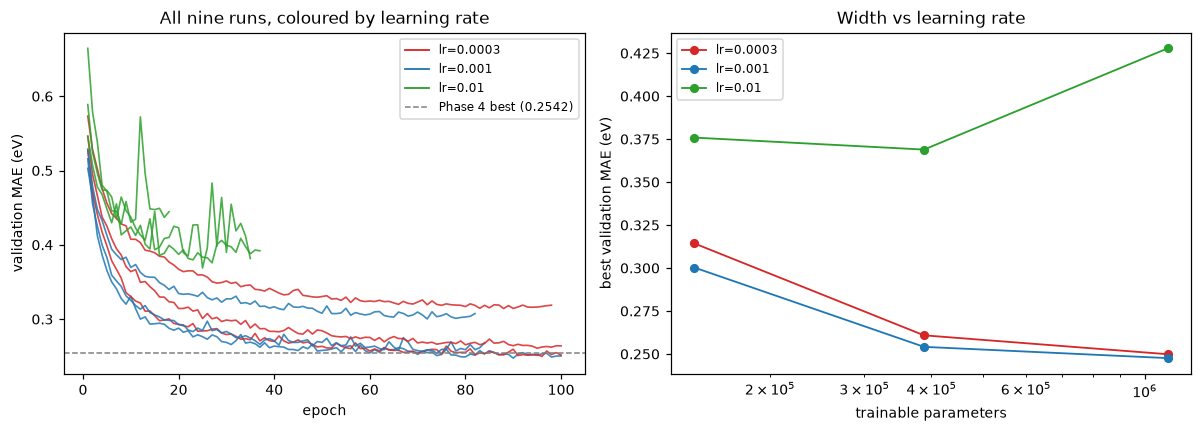

In [4]:
from mlflow.tracking import MlflowClient

client = MlflowClient(tracking_uri=tracking_uri())
runs = search_runs(filter_string="tags.sweep = 'lr-width'")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rates = sorted(runs["params.learning_rate"].unique(), key=float)
colours = dict(zip(rates, ["tab:red", "tab:blue", "tab:green"]))

for _, row in runs.iterrows():
    # get_metric_history returns the stepped series: this is the payoff of
    # logging metrics per epoch rather than only at the end.
    history = client.get_metric_history(row["run_id"], "mae_ev")
    epochs = [m.step for m in history]
    mae = [m.value for m in history]
    axes[0].plot(epochs, mae, lw=1.1, alpha=0.85,
                 color=colours[row["params.learning_rate"]])

for rate, colour in colours.items():
    axes[0].plot([], [], color=colour, lw=1.2, label=f"lr={rate}")
axes[0].axhline(0.2542, color="grey", ls="--", lw=1, label="Phase 4 best (0.2542)")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation MAE (eV)")
axes[0].set_title("All nine runs, coloured by learning rate")
axes[0].legend(fontsize=8)

# Final MAE against parameter count, one line per learning rate.
runs = runs.assign(n_parameters=runs["params.n_parameters"].astype(int))
for rate, colour in colours.items():
    subset = runs[runs["params.learning_rate"] == rate].sort_values("n_parameters")
    axes[1].plot(subset["n_parameters"], subset["metrics.best_val_mae_ev"],
                 "o-", color=colour, lw=1.2, ms=5, label=f"lr={rate}")
axes[1].set_xscale("log")
axes[1].set_xlabel("trainable parameters")
axes[1].set_ylabel("best validation MAE (eV)")
axes[1].set_title("Width vs learning rate")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Three things to read off these.

**The `lr=0.01` runs die young.** Their best epochs are 8, 25 and 27, and early
stopping cut all three before epoch 40. That is a step size too large for this loss
surface: the optimiser overshoots, validation stops improving, patience expires.
The widest network is the *worst* of the three (0.4278 eV, best at epoch 8) —
the more parameters, the more there is to destabilise.

**Width helps, but only once the step size is sane.** In the right-hand panel the
`1e-3` and `3e-4` lines fall monotonically as the network grows. The `1e-2` line
rises. The two axes interact, which is precisely the argument for a grid rather
than tuning one axis at a time and assuming the other is independent.

**`1e-3` is an interior optimum.** `1e-2` overshoots, `3e-4` is simply too slow —
at every width it lands short of the `1e-3` run while using more epochs to get
there. The best value being in the middle of the range rather than at an edge is
the sign the range was chosen sensibly; had `3e-4` won, the honest next step would
be extending the grid downward rather than declaring it best.

### A limitation the ranking hides

Three runs hit the 100-epoch cap — and they are three of the top four, with best
epochs at 90, 95 and 96. They were **still improving when the budget cut them off**.

So the top of this table is not a comparison of converged models. It is partly a
comparison of which configurations happened to make the most progress inside a
fixed epoch budget. The `lr=1e-3, 512x256x128` run early-stopped at 84 epochs
having genuinely converged; the winner did not. `0.2476 eV` is a floor for that
configuration, not its best possible score.

The clean next experiment is to raise `max_epochs` and re-run the top few. Nothing
about doing that costs us the current results — which is the entire point of
having a run store instead of a printed table.

## Querying the store

`search_runs` takes MLflow's own small query language over params, metrics and
tags. This is the thing a printed table cannot do at any size: ask a question of
runs that finished before you knew you would ask it.

In [5]:
narrow = search_runs(
    filter_string="params.learning_rate = '0.001' and metrics.best_val_mae_ev < 0.3",
    order_by=["metrics.best_val_mae_ev ASC"],
)

display(
    narrow[[
        "tags.mlflow.runName", "params.hidden_sizes", "params.n_parameters",
        "metrics.best_val_mae_ev", "metrics.best_epoch", "metrics.train_seconds",
    ]]
    .rename(columns=lambda c: c.split(".")[-1])
    .style.format({"best_val_mae_ev": "{:.4f}", "train_seconds": "{:.0f}"})
    .set_caption("lr=1e-3 runs that beat 0.30 eV")
)

,runName,hidden_sizes,n_parameters,best_val_mae_ev,best_epoch,train_seconds
0,lr-width-le0.001-hi1024x512x256,"(1024, 512, 256)",1102849,0.2476,90.000000,907
1,lr-width-le0.001-hi512x256x128,"(512, 256, 128)",387585,0.2542,74.000000,390


## From a row in a table back to the weights

This is the loop Phase 4 left open. There, going from "the MSE run was best" to
"load the right file" meant knowing that `molecular_net_mse.pt` was the one — a
filename convention held together by care. Here the run id is the handle, and it
survives the kernel.

In [6]:
best = best_run()
print(f"best run   : {best['tags.mlflow.runName']}")
print(f"run id     : {best['run_id']}")
print(f"lr         : {best['params.learning_rate']}")
print(f"hidden     : {best['params.hidden_sizes']}")
print(f"parameters : {int(best['params.n_parameters']):,}")
print(f"val MAE    : {best['metrics.best_val_mae_ev']:.4f} eV")

# Fetches the .pt artifact attached to that run and loads it. Note that the
# loading is still model.load_artifact -- MLflow only located the file, which is
# what keeps Phase 6 free of any dependency on it.
model, scaler, metadata = load_run_artifact(best["run_id"])
predicted = predict(model, scaler, features[validation_rows])

print(f"\nreloaded   : {metadata}")
print(f"recomputed MAE from the reloaded checkpoint: "
      f"{np.abs(predicted - actual).mean():.4f} eV")

best run   : lr-width-le0.001-hi1024x512x256
run id     : bbe66d9a291244fbbddc9d8556c5d7e0
lr         : 0.001
hidden     : (1024, 512, 256)
parameters : 1,102,849
val MAE    : 0.2476 eV



reloaded   : ArtifactMetadata(representation='sorted_coulomb', target='lumo', n_features=435, hidden_sizes=(1024, 512, 256), dropout=0.1, loss_name='mse', split_seed=0, torch_seed=0, epochs_trained=100, best_epoch=90, validation_mae_ev=0.2476282933006721)
recomputed MAE from the reloaded checkpoint: 0.2476 eV


The recomputed MAE matching the logged metric is the check that matters: the
number in the database and the weights on disk describe the same model.

## Comparing against the earlier phases

Same validation split, same target, three phases of modelling.

In [7]:
ladder = pd.DataFrame([
    {"phase": "3 — GBM on sorted Coulomb", "val_mae_ev": 0.3692},
    {"phase": "4 — network, hand-picked config", "val_mae_ev": 0.2542},
    {"phase": "5 — best of a 9-run sweep",
     "val_mae_ev": float(best["metrics.best_val_mae_ev"])},
])
ladder["improvement_vs_phase_3"] = (
    1 - ladder["val_mae_ev"] / 0.3692
).map("{:.1%}".format)

display(
    ladder.style.format({"val_mae_ev": "{:.4f}"}).hide(axis="index")
    .set_caption("Validation MAE across phases (test split still sealed)")
)

phase,val_mae_ev,improvement_vs_phase_3
3 — GBM on sorted Coulomb,0.3692,0.0%
"4 — network, hand-picked config",0.2542,31.1%
5 — best of a 9-run sweep,0.2476,32.9%


The shape of that ladder is the honest summary of the modelling work so far:

| step | change | improvement |
|---|---|---|
| Phase 3 → 4 | GBM → neural network | **31.2%** |
| Phase 4 → 5 | tuning lr and width | **2.6%** |

Nearly all the gain came from changing the model class. An hour of systematic
hyperparameter search added a bit under three percent on top, and part of even
that is unconverged runs benefiting from a larger network rather than a better
setting.

None of which makes Phase 5 wasted effort — but the value it delivered is not the
0.0066 eV. It is that the nine runs are on disk, queryable, each one linked to the
exact configuration and checkpoint that produced it, so the next question asked of
this model does not start from scratch. That infrastructure is the deliverable.
The metric improvement is a by-product, and a small one.

Every number here is a **validation** score. Choosing a learning rate by reading
these is exactly the kind of decision that spends a split's ability to estimate
performance on unseen data — which is why the test split is still untouched going
into Phase 6, and why it will be read exactly once.

## The UI

```bash
mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db
```

Then `http://127.0.0.1:5000`. The run table sorts and filters on any logged param
or metric; selecting several runs and choosing *Chart* plots their metric series
on shared axes. It is reading the same database `search_runs` just queried — the
UI is a convenience over the store, not the store itself, which is why none of the
analysis above needed it.

## Two things deliberately not used

**Autologging.** `mlflow.pytorch.autolog()` is one line and would have captured
most of the above. `tracking.py` makes about eight explicit calls instead. The
trade is real and it is not obvious which way it should go — autolog is
strictly less code. But this is a project whose stated bar is being able to
explain every part of it, and a run record you cannot account for is worse than no
run record.

**The model registry and `mlflow.pytorch.log_model`.** That would store the
network in MLflow's own packaging with a `python_function` flavour. The Phase 4
`.pt` already bundles the weights with the scaler that must accompany them, so the
sweep logs that file as a plain artifact and records the input signature next to
it.

The consequence is the point, and it is what Phase 6 inherits: the API will load a
checkpoint with `model.load_artifact` and **never import MLflow**. Tracking is a
development-time concern. The container that answers prediction requests should
not carry a tracking client, a database driver and a web server it will never use
— which is also why `mlflow` sits in the `dev` dependencies, not the runtime ones.